# Law RAG Evaluation Notebook

Notebook này dùng để chạy evaluation và vẽ biểu đồ trực quan từ file JSON trong `output/eval/runs`.

Các biểu đồ chính:
- Metric summary
- Lowest scoring cases
- Groundedness by case
- Category averages
- Latency by case


In [1]:
from __future__ import annotations

import json
import statistics
import subprocess
import sys
import time
from collections import defaultdict
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Thiếu matplotlib. Chạy: pip install -r requirements.txt") from exc

ROOT_DIR = Path.cwd()
RUNS_DIR = ROOT_DIR / "output" / "eval" / "runs"
CHARTS_DIR = ROOT_DIR / "output" / "eval" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## 1. Chạy Evaluation

Mặc định cell dưới **không chạy lại eval** để tránh tốn thời gian/API. Nếu muốn chạy lại, đổi `RUN_EVAL = True`.

In [2]:
RUN_EVAL = False

EVAL_ARGS = [
    sys.executable,
    "evaluate_law_rag.py",
    "--retrieval-mode", "hybrid",
    "--top-k", "5",
]

if RUN_EVAL:
    started = time.time()
    completed = subprocess.run(EVAL_ARGS, cwd=ROOT_DIR, text=True, capture_output=True)
    print(completed.stdout)
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError(f"Evaluation failed with exit code {completed.returncode}")
    print(f"Evaluation finished in {time.time() - started:.1f}s")
else:
    print("Skipping eval run. Loading latest JSON report from output/eval/runs.")


Skipping eval run. Loading latest JSON report from output/eval/runs.


## 2. Load Report JSON

In [3]:
def latest_report_path(runs_dir: Path) -> Path:
    reports = sorted(runs_dir.glob("eval-*.json"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not reports:
        raise FileNotFoundError("Không tìm thấy eval report trong output/eval/runs. Hãy chạy evaluate_law_rag.py trước.")
    return reports[0]

REPORT_PATH = latest_report_path(RUNS_DIR)
payload = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
summary = payload.get("summary", {})
results = payload.get("results", [])

print(f"Report: {REPORT_PATH}")
print(f"Cases: {summary.get('case_count', len(results))}")
print(json.dumps(summary.get("scores", {}), ensure_ascii=False, indent=2))


Report: c:\Users\Admin\Desktop\Law-RAG\output\eval\runs\eval-1778645257.json
Cases: 48
{
  "precision_at_3": 0.45,
  "precision_at_5": 0.34,
  "recall_at_3": 0.9,
  "recall_at_5": 0.93,
  "mrr": 0.81,
  "ndcg_at_5": 0.73,
  "best_reference_token_iou": 0.35,
  "duplicate_rate": 0.03,
  "retrieval_relevance": 4.56,
  "citation_accuracy": 4.71,
  "groundedness": 3.21,
  "answer_correctness": 4.98,
  "answer_relevance": 5,
  "completeness": 4.98,
  "no_overclaiming": 4,
  "overall": 4.45
}


## 3. Helper Functions

In [4]:
def score(item: dict, key: str, default: float | None = None) -> float | None:
    value = item.get("scores", {}).get(key, default)
    return value if isinstance(value, (int, float)) else default


def case_label(item: dict) -> str:
    return str(item.get("case_id") or item.get("question") or "unknown")


def save_current_figure(name: str) -> Path:
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")
    return path


def mean(values: list[float]) -> float | None:
    return round(statistics.mean(values), 3) if values else None


successful_results = [item for item in results if "error" not in item]
failed_results = [item for item in results if "error" in item]
print(f"Successful cases: {len(successful_results)}")
print(f"Failed cases: {len(failed_results)}")


Successful cases: 48
Failed cases: 0


## 4. Metric Summary

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\metrics_summary.png


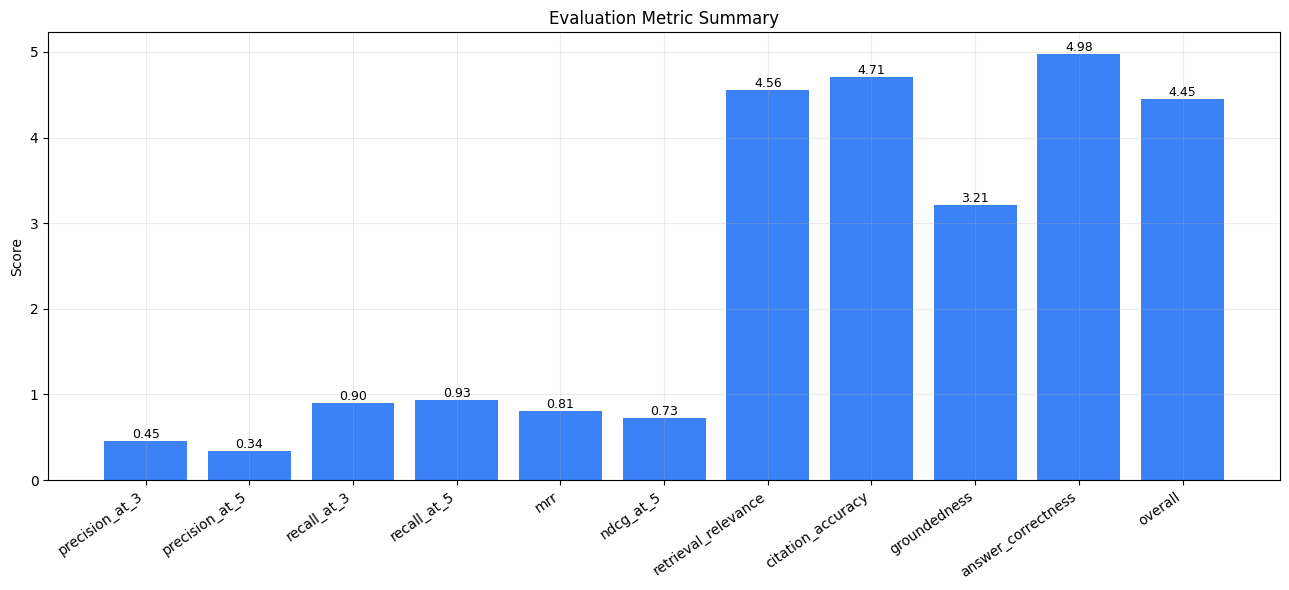

In [5]:
metric_keys = [
    "precision_at_3",
    "precision_at_5",
    "recall_at_3",
    "recall_at_5",
    "mrr",
    "ndcg_at_5",
    "retrieval_relevance",
    "citation_accuracy",
    "groundedness",
    "answer_correctness",
    "overall",
]

scores = summary.get("scores", {})
labels = [key for key in metric_keys if isinstance(scores.get(key), (int, float))]
values = [scores[key] for key in labels]

plt.figure(figsize=(13, 6))
bars = plt.bar(labels, values, color="#3b82f6")
plt.title("Evaluation Metric Summary")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom", fontsize=9)
save_current_figure("metrics_summary.png")
plt.show()


## 5. Lowest Scoring Cases

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\lowest_overall_cases.png


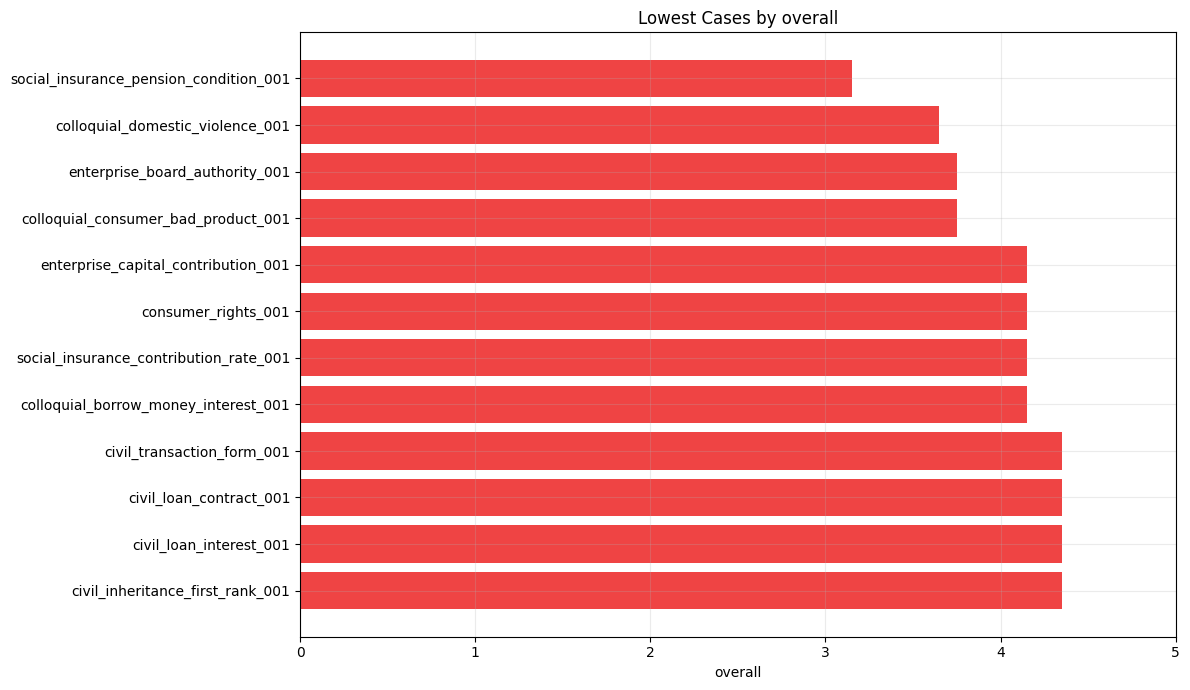

social_insurance_pension_condition_001 bao_hiem_xa_hoi 3.15
colloquial_domestic_violence_001 gia_dinh_colloquial 3.65
enterprise_board_authority_001 doanh_nghiep 3.75
colloquial_consumer_bad_product_001 bao_ve_nguoi_tieu_dung_colloquial 3.75
enterprise_capital_contribution_001 doanh_nghiep 4.15
consumer_rights_001 bao_ve_nguoi_tieu_dung 4.15
social_insurance_contribution_rate_001 bao_hiem_xa_hoi 4.15
colloquial_borrow_money_interest_001 dan_su_colloquial 4.15
civil_transaction_form_001 dan_su 4.35
civil_loan_contract_001 dan_su 4.35
civil_loan_interest_001 dan_su 4.35
civil_inheritance_first_rank_001 dan_su 4.35


In [6]:
LOWEST_BY = "overall"
lowest_cases = sorted(successful_results, key=lambda item: score(item, LOWEST_BY, 0) or 0)[:12]
labels = [case_label(item) for item in lowest_cases]
values = [score(item, LOWEST_BY, 0) or 0 for item in lowest_cases]

plt.figure(figsize=(12, 7))
plt.barh(labels[::-1], values[::-1], color="#ef4444")
plt.title(f"Lowest Cases by {LOWEST_BY}")
plt.xlabel(LOWEST_BY)
plt.xlim(0, 5)
save_current_figure("lowest_overall_cases.png")
plt.show()

for item in lowest_cases:
    print(case_label(item), item.get("category"), item.get("scores", {}).get(LOWEST_BY))


## 6. Groundedness by Case

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\groundedness_by_case.png


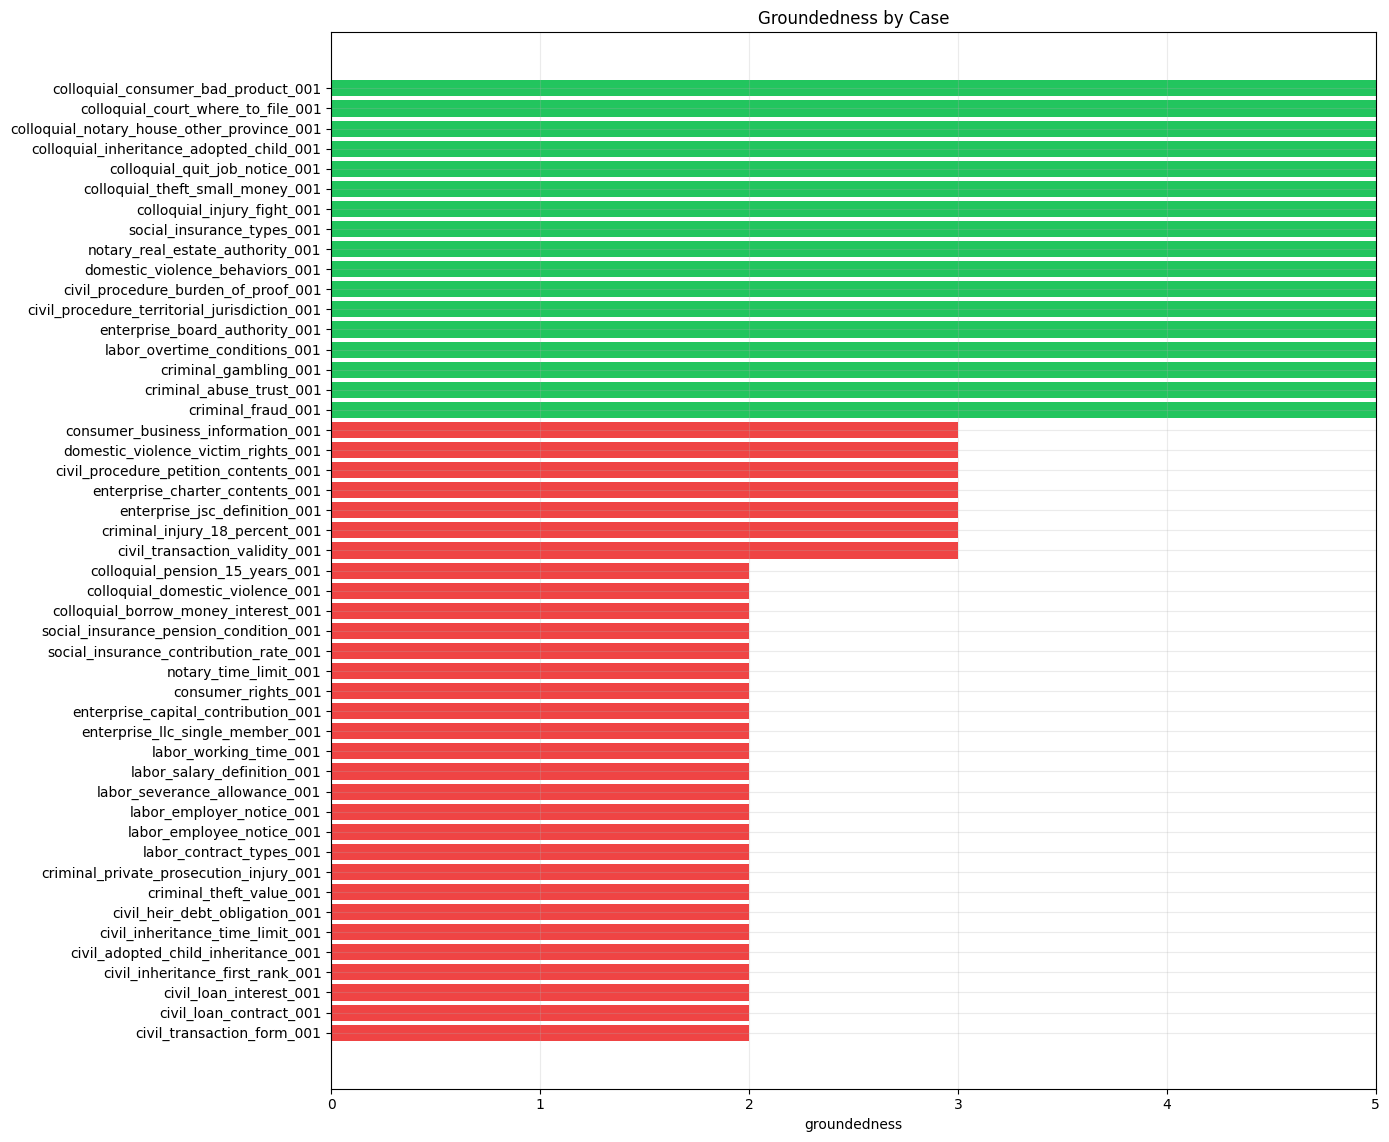

In [7]:
grounded_cases = [item for item in successful_results if score(item, "groundedness") is not None]
grounded_cases = sorted(grounded_cases, key=lambda item: score(item, "groundedness", 0) or 0)
labels = [case_label(item) for item in grounded_cases]
values = [score(item, "groundedness", 0) or 0 for item in grounded_cases]

plt.figure(figsize=(14, max(7, len(labels) * 0.24)))
colors = ["#ef4444" if value <= 3 else "#22c55e" for value in values]
plt.barh(labels, values, color=colors)
plt.title("Groundedness by Case")
plt.xlabel("groundedness")
plt.xlim(0, 5)
save_current_figure("groundedness_by_case.png")
plt.show()


## 7. Category Averages

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\category_scores.png


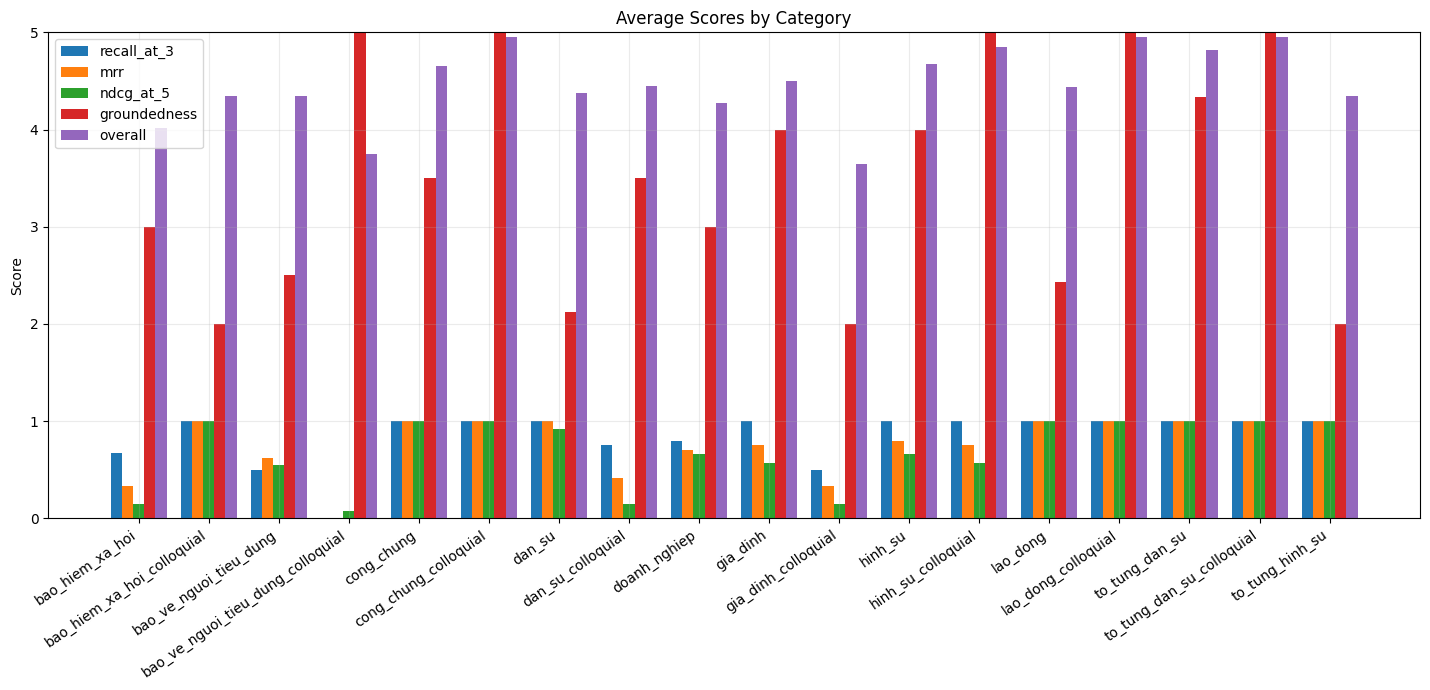

In [8]:
category_values: dict[str, dict[str, list[float]]] = defaultdict(lambda: defaultdict(list))
category_metric_keys = ["recall_at_3", "mrr", "ndcg_at_5", "groundedness", "overall"]

for item in successful_results:
    category = str(item.get("category") or "unknown")
    for key in category_metric_keys:
        value = score(item, key)
        if value is not None:
            category_values[category][key].append(value)

categories = sorted(category_values)
x = list(range(len(categories)))
width = 0.16

plt.figure(figsize=(max(12, len(categories) * 0.8), 7))
for offset, key in enumerate(category_metric_keys):
    values = [mean(category_values[category][key]) or 0 for category in categories]
    positions = [index + (offset - 2) * width for index in x]
    plt.bar(positions, values, width=width, label=key)

plt.title("Average Scores by Category")
plt.ylabel("Score")
plt.xticks(x, categories, rotation=35, ha="right")
plt.ylim(0, 5)
plt.legend()
save_current_figure("category_scores.png")
plt.show()


## 8. Colloquial vs Standard Questions

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\colloquial_vs_standard.png


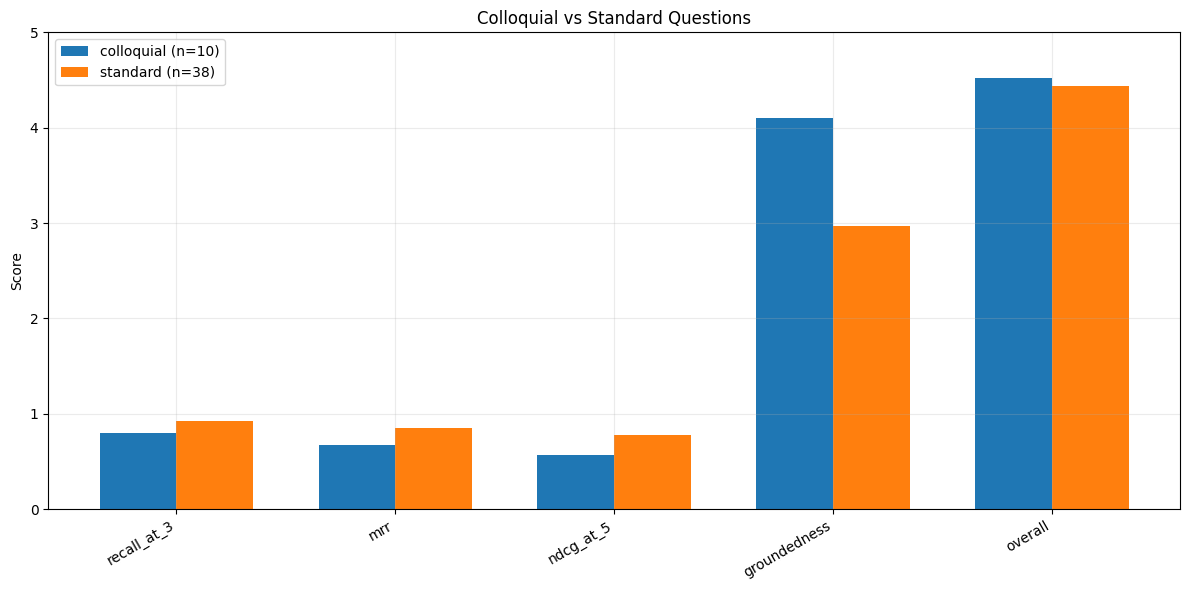

In [9]:
groups = {
    "colloquial": [item for item in successful_results if "colloquial" in str(item.get("category", "")) or "colloquial" in case_label(item)],
    "standard": [item for item in successful_results if "colloquial" not in str(item.get("category", "")) and "colloquial" not in case_label(item)],
}
compare_keys = ["recall_at_3", "mrr", "ndcg_at_5", "groundedness", "overall"]

x = list(range(len(compare_keys)))
width = 0.35
plt.figure(figsize=(12, 6))
for index, (group_name, items) in enumerate(groups.items()):
    values = []
    for key in compare_keys:
        group_scores = [score(item, key) for item in items if score(item, key) is not None]
        values.append(mean(group_scores) or 0)
    positions = [pos + (index - 0.5) * width for pos in x]
    plt.bar(positions, values, width=width, label=f"{group_name} (n={len(items)})")

plt.title("Colloquial vs Standard Questions")
plt.ylabel("Score")
plt.xticks(x, compare_keys, rotation=30, ha="right")
plt.ylim(0, 5)
plt.legend()
save_current_figure("colloquial_vs_standard.png")
plt.show()


## 9. Latency by Case

Saved: c:\Users\Admin\Desktop\Law-RAG\output\eval\charts\latency_by_case.png


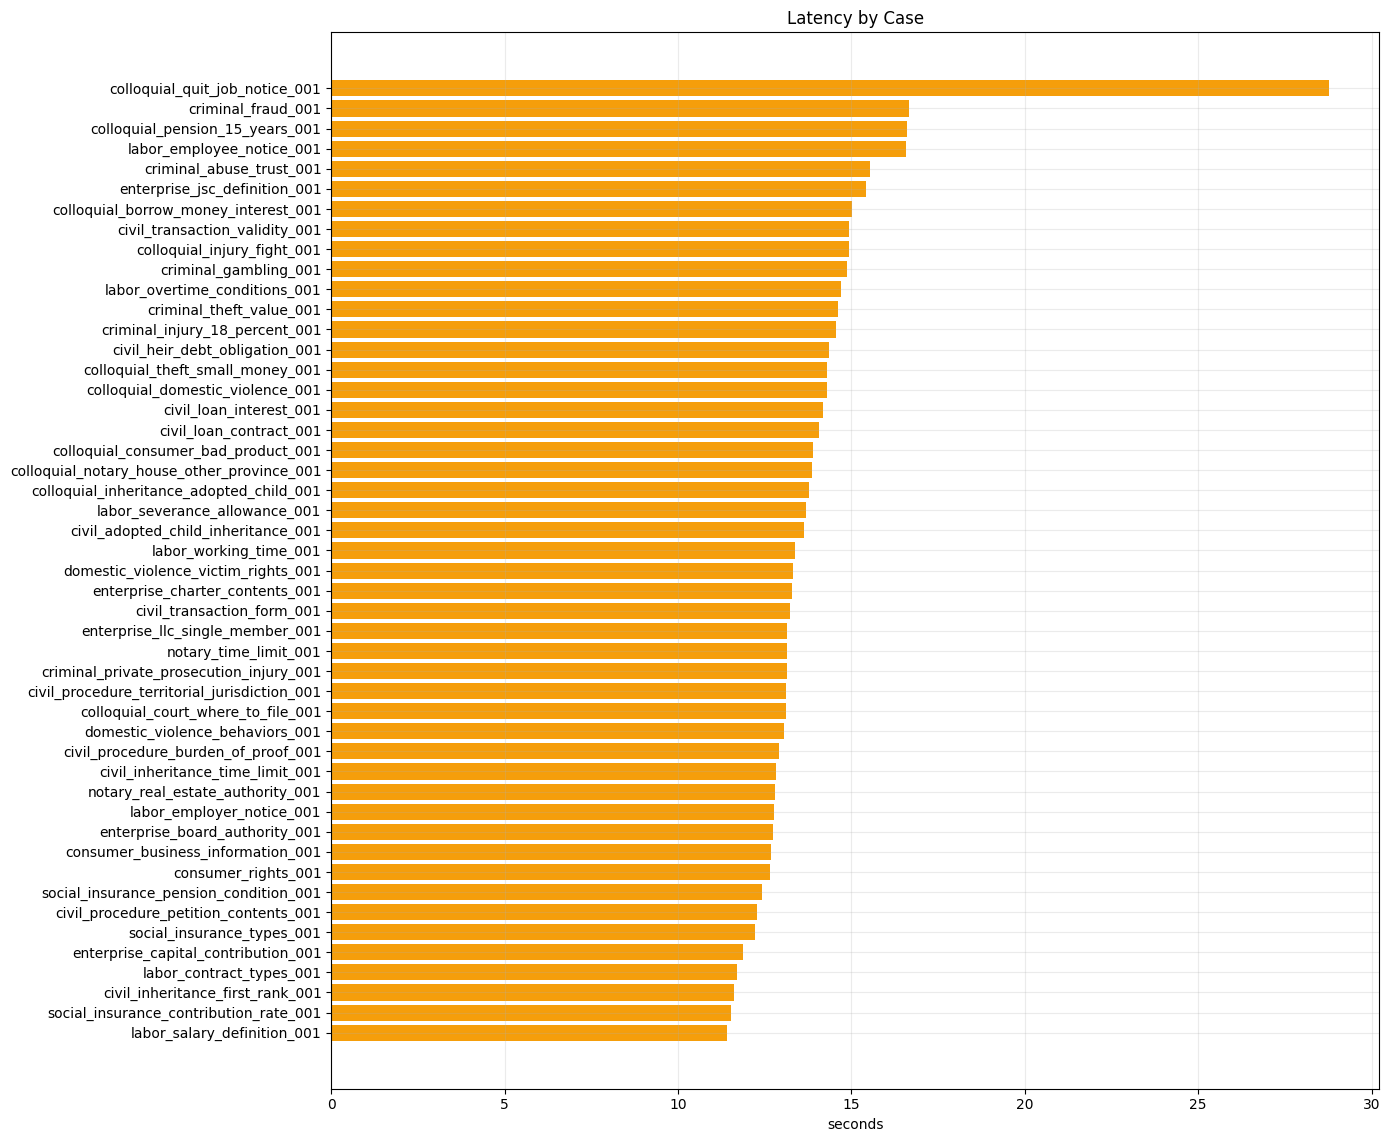

Average latency: 13.95s
Max latency: 28.78s


In [10]:
latency_items = [item for item in successful_results if isinstance(item.get("metadata", {}).get("latency_ms"), (int, float))]
latency_items = sorted(latency_items, key=lambda item: item["metadata"]["latency_ms"], reverse=True)
labels = [case_label(item) for item in latency_items]
values = [item["metadata"]["latency_ms"] / 1000 for item in latency_items]

plt.figure(figsize=(14, max(7, len(labels) * 0.24)))
plt.barh(labels[::-1], values[::-1], color="#f59e0b")
plt.title("Latency by Case")
plt.xlabel("seconds")
save_current_figure("latency_by_case.png")
plt.show()

if values:
    print(f"Average latency: {statistics.mean(values):.2f}s")
    print(f"Max latency: {max(values):.2f}s")


## 10. Quick Failure Table

In [11]:
problem_cases = []
for item in successful_results:
    if (score(item, "overall", 5) or 5) < 4 or (score(item, "groundedness", 5) or 5) <= 3 or (score(item, "recall_at_5", 1) or 1) < 1:
        problem_cases.append(item)

for item in sorted(problem_cases, key=lambda row: (score(row, "overall", 0) or 0, score(row, "groundedness", 0) or 0)):
    scores = item.get("scores", {})
    print("-", case_label(item))
    print("  category:", item.get("category"))
    print("  overall:", scores.get("overall"), "groundedness:", scores.get("groundedness"), "recall@5:", scores.get("recall_at_5"), "mrr:", scores.get("mrr"))
    print("  missing_answer_points:", scores.get("missing_answer_points", []))
    print("  unsupported_citations:", scores.get("unsupported_citations", []))
    print("  unsupported_numbers:", scores.get("unsupported_numbers", []))


- social_insurance_pension_condition_001
  category: bao_hiem_xa_hoi
  overall: 3.15 groundedness: 2 recall@5: 0.0 mrr: 0.0
  missing_answer_points: []
  unsupported_citations: ['article:169', 'clause:2']
  unsupported_numbers: []
- colloquial_domestic_violence_001
  category: gia_dinh_colloquial
  overall: 3.65 groundedness: 2 recall@5: 0.5 mrr: 0.333
  missing_answer_points: []
  unsupported_citations: ['article:3']
  unsupported_numbers: []
- enterprise_board_authority_001
  category: doanh_nghiep
  overall: 3.75 groundedness: 5 recall@5: 0.0 mrr: 0.0
  missing_answer_points: []
  unsupported_citations: []
  unsupported_numbers: []
- colloquial_consumer_bad_product_001
  category: bao_ve_nguoi_tieu_dung_colloquial
  overall: 3.75 groundedness: 5 recall@5: 0.0 mrr: 0.0
  missing_answer_points: []
  unsupported_citations: []
  unsupported_numbers: []
- enterprise_capital_contribution_001
  category: doanh_nghiep
  overall: 4.15 groundedness: 2 recall@5: 1.0 mrr: 0.5
  missing_answer_p